
# Proposal Voting Simulation — Direct vs Delegated (Frozen / Optimal / Probabilistic)

This notebook computes **stake-weighted votes per epoch** for a simple proposal rule:

> A voter **votes FOR** if their opinion \(O\in[0,0.5]\). Otherwise they vote **AGAINST**.

We produce **four graphs** (time-series over epochs) for these data sources:

1) **Direct voting (no delegation)**: Each *delegator and DRep* votes for themselves, with their **own stake**.  
   *(Inputs: `csv_out/delegators_state.csv`, `csv_out/dreps_state.csv`)*

2) **Frozen delegation**: Only **DReps** vote, weighted by **\(W'\)** from the frozen mapping.  
   *(Input: `csv_out_frozen/dreps_state_with_wprime_frozen.csv`)*

3) **Optimal delegation**: Only **DReps** vote, weighted by **\(W'\)** from optimal (closest-by-opinion) mapping.  
   *(Input: `csv_out_optimal/dreps_state_with_wprime.csv`)*

4) **Probabilistic delegation**: Only **DReps** vote, weighted by **\(W'\)** from the probabilistic mapping.  
   *(Input: `csv_out_probabilistic/dreps_wprime_probabilistic.csv`)*

The x-axis is **epoch**; the y-axis is **total voting stake** (FOR vs AGAINST).

> Default proposal range: **[0, 0.5]**. You can change it in the parameters below.


In [52]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- Parameters --------
THRESH_LOW  = 0.0
THRESH_HIGH = 0.5   # proposal passes if voter opinion O in [0, 0.5]

# Paths
CSV_DIR_BASE          = Path("csv_out")
CSV_DIR_FROZEN        = Path("csv_out_frozen")
CSV_DIR_OPTIMAL       = Path("csv_out_optimal")
CSV_DIR_PROBABILISTIC = Path("csv_out_probabilistic")

# Inputs
DELEGATORS_STATE = CSV_DIR_BASE / "delegators_state.csv"
DREPS_STATE      = CSV_DIR_BASE / "dreps_state.csv"

DREPS_WP_FROZEN  = CSV_DIR_FROZEN / "dreps_state_with_wprime_frozen.csv"
DREPS_WP_OPTIMAL = CSV_DIR_OPTIMAL / "dreps_state_with_wprime.csv"
DREPS_WP_PROB    = CSV_DIR_PROBABILISTIC / "dreps_wprime_probabilistic.csv"

print("Expecting inputs:")
print(" -", DELEGATORS_STATE.resolve())
print(" -", DREPS_STATE.resolve())
print(" -", DREPS_WP_FROZEN.resolve())
print(" -", DREPS_WP_OPTIMAL.resolve())
print(" -", DREPS_WP_PROB.resolve())


Expecting inputs:
 - /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out/delegators_state.csv
 - /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out/dreps_state.csv
 - /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out_frozen/dreps_state_with_wprime_frozen.csv
 - /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out_optimal/dreps_state_with_wprime.csv
 - /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out_probabilistic/dreps_wprime_probabilistic.csv


In [53]:

def stake_for_against(timeseries_df: pd.DataFrame, id_col: str, opinion_col: str, stake_col: str):
    """Return dataframe with columns: epoch, for_stake, against_stake.
    Sum stake over voters per epoch based on opinion threshold [THRESH_LOW, THRESH_HIGH]."""
    df = timeseries_df[['epoch', opinion_col, stake_col]].copy()
    df[stake_col] = df[stake_col].astype(float)
    df['is_for'] = (df[opinion_col].astype(float) >= THRESH_LOW) & (df[opinion_col].astype(float) <= THRESH_HIGH)
    grp = df.groupby('epoch', as_index=False).agg(
        for_stake   = (stake_col, lambda s: float(s[df['is_for'].loc[s.index]].sum())),
        against_stake = (stake_col, lambda s: float(s[~df['is_for'].loc[s.index]].sum()))
    )
    # Ensure numeric
    grp['for_stake'] = grp['for_stake'].astype(float)
    grp['against_stake'] = grp['against_stake'].astype(float)
    return grp.sort_values('epoch')


In [54]:

# ---- Load direct voting inputs ----
deleg_df = pd.read_csv(DELEGATORS_STATE)  # epoch, delegator_id, opinion, stake, s
dreps_df = pd.read_csv(DREPS_STATE)       # epoch, drep_id, opinion, stake

# ---- Compute direct voting (delegators + dreps, each with own stake) ----
direct_deleg = stake_for_against(deleg_df, id_col='delegator_id', opinion_col='opinion', stake_col='stake')
direct_dreps = stake_for_against(dreps_df,  id_col='drep_id',       opinion_col='opinion', stake_col='stake')

direct = direct_deleg.merge(direct_dreps, on='epoch', how='outer', suffixes=('_deleg','_dreps')).fillna(0.0)
direct['for_stake']     = direct['for_stake_deleg'] + direct['for_stake_dreps']
direct['against_stake'] = direct['against_stake_deleg'] + direct['against_stake_dreps']
direct = direct[['epoch','for_stake','against_stake']].sort_values('epoch')

direct.head()

,epoch,for_stake,against_stake
0,0,494.576659,539.423499
1,1,489.986731,544.013427
2,2,486.978273,547.021885
3,3,481.570394,552.429764
4,4,476.367605,557.632553


In [55]:

# ---- Frozen / Optimal / Probabilistic: only DReps voting with W' ----
dreps_frozen = pd.read_csv(DREPS_WP_FROZEN)     # epoch, drep_id, opinion, ..., Wprime
dreps_opt    = pd.read_csv(DREPS_WP_OPTIMAL)    # epoch, drep_id, opinion, ..., Wprime
dreps_prob   = pd.read_csv(DREPS_WP_PROB)       # epoch, drep_id, opinion, ..., Wprime

frozen = stake_for_against(dreps_frozen, id_col='drep_id', opinion_col='opinion', stake_col='Wprime')
optimal = stake_for_against(dreps_opt,    id_col='drep_id', opinion_col='opinion', stake_col='Wprime')
prob    = stake_for_against(dreps_prob,   id_col='drep_id', opinion_col='opinion', stake_col='Wprime')

frozen.head(), optimal.head(), prob.head()

(   epoch   for_stake  against_stake
 0      0  512.664361     524.623880
 1      1  296.275043     741.013197
 2      2   95.830215     941.458025
 3      3   35.925606    1001.362635
 4      4    0.000000    1037.288241,
    epoch   for_stake  against_stake
 0      0  512.664361     524.623880
 1      1  504.827776     532.460464
 2      2  452.193905     585.094336
 3      3  513.406256     523.881984
 4      4    0.000000    1037.288241,
    epoch   for_stake  against_stake
 0      0  512.664361     524.623880
 1      1  307.050509     730.237731
 2      2  139.331966     897.956275
 3      3  114.778046     922.510194
 4      4    0.000000    1037.288241)

In [56]:

# ---- Plotting helpers ----
def plot_for_against(ax, df, title: str):
    ax.plot(df['epoch'], df['for_stake'],     label='For',     color='green')
    ax.plot(df['epoch'], df['against_stake'], label='Against', color='red')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Stake-weighted votes")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)


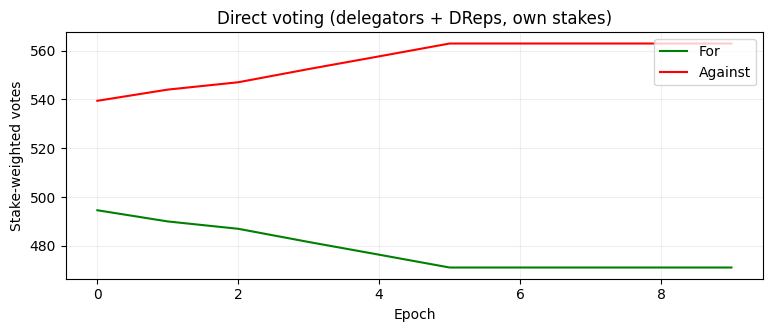

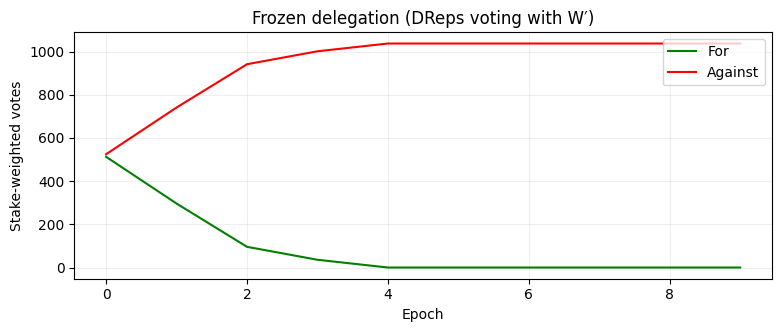

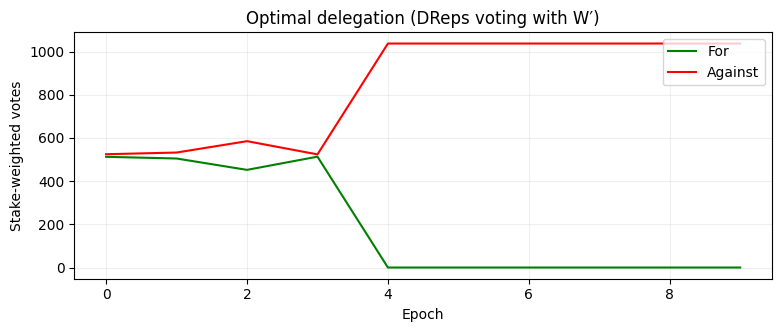

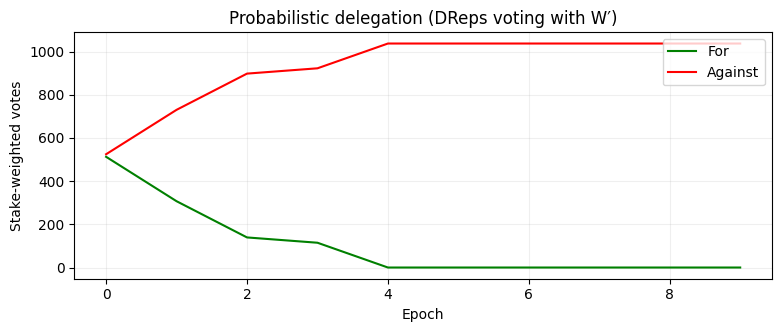

In [57]:

# ---- Make 4 graphs (one figure per mode) ----

# 1) Direct voting
fig1, ax1 = plt.subplots(figsize=(9, 3.2))
plot_for_against(ax1, direct, "Direct voting (delegators + DReps, own stakes)")
plt.show()

# 2) Frozen delegation (DReps with W')
fig2, ax2 = plt.subplots(figsize=(9, 3.2))
plot_for_against(ax2, frozen, "Frozen delegation (DReps voting with W′)")
plt.show()

# 3) Optimal delegation (DReps with W')
fig3, ax3 = plt.subplots(figsize=(9, 3.2))
plot_for_against(ax3, optimal, "Optimal delegation (DReps voting with W′)")
plt.show()

# 4) Probabilistic delegation (DReps with W')
fig4, ax4 = plt.subplots(figsize=(9, 3.2))
plot_for_against(ax4, prob, "Probabilistic delegation (DReps voting with W′)")
plt.show()


--- Generating 'FOR' Percentage Plots ---


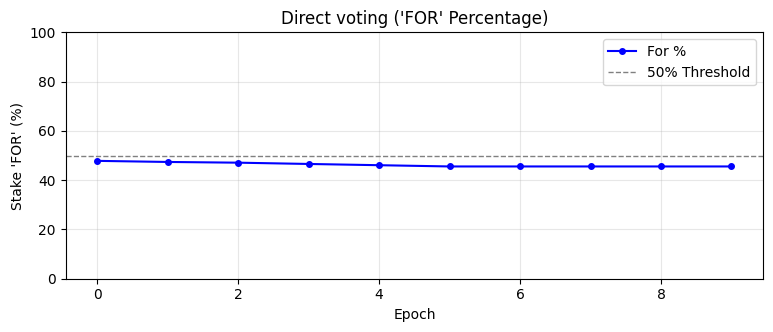

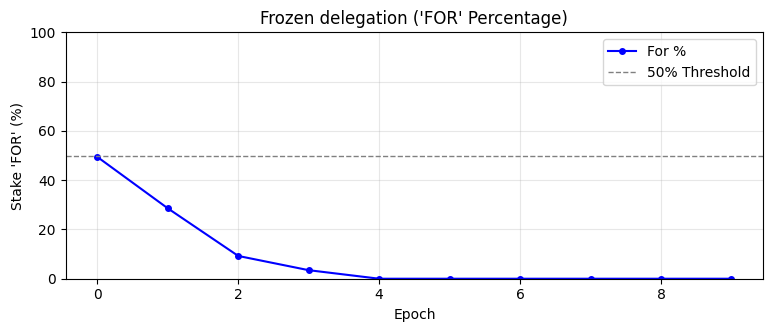

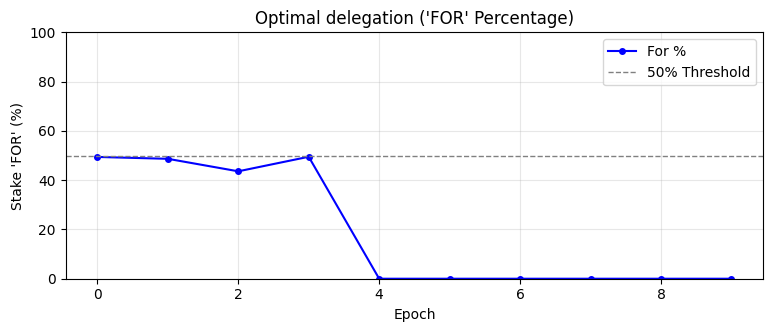

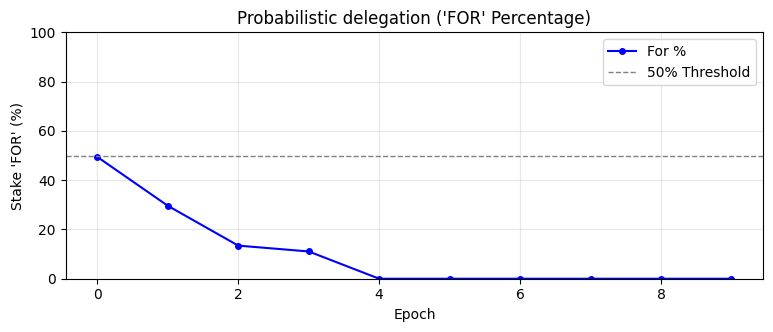

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Helper function to calculate 'FOR' percentage ----
def add_for_percentage(df):
    """Returns a new DataFrame with a 'for_pct' column."""
    df_new = df.copy()
    total_stake = df_new['for_stake'] + df_new['against_stake']
    
    # Use np.where to avoid division by zero if total_stake is 0
    # Multiply by 100 to get percentage
    df_new['for_pct'] = np.where(
        total_stake == 0, 
        0, 
        (df_new['for_stake'] / total_stake) * 100
    )
    return df_new

# ---- Calculate percentages for all models ----
direct_pct  = add_for_percentage(direct)
frozen_pct  = add_for_percentage(frozen)
optimal_pct = add_for_percentage(optimal)
prob_pct    = add_for_percentage(prob)

# ---- New plotting helper for percentages ----
def plot_for_percentage(ax, df, title: str):
    """Plots the 'FOR' percentage over epochs."""
    ax.plot(df['epoch'], df['for_pct'], label='For %', color='blue', marker='o', markersize=4, linestyle='-')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Stake 'FOR' (%)")
    
    # Set Y-axis from 0 to 100
    ax.set_ylim(0, 100)
    
    # Add a 50% line for reference
    ax.axhline(50, color='grey', linestyle='--', linewidth=1.0, label='50% Threshold')
    
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

# ---- Make 4 graphs for 'FOR' percentage ----

print("--- Generating 'FOR' Percentage Plots ---")

# 1) Direct voting %
fig_pct1, ax_pct1 = plt.subplots(figsize=(9, 3.2))
plot_for_percentage(ax_pct1, direct_pct, "Direct voting ('FOR' Percentage)")
plt.show()

# 2) Frozen delegation %
fig_pct2, ax_pct2 = plt.subplots(figsize=(9, 3.2))
plot_for_percentage(ax_pct2, frozen_pct, "Frozen delegation ('FOR' Percentage)")
plt.show()

# 3) Optimal delegation %
fig_pct3, ax_pct3 = plt.subplots(figsize=(9, 3.2))
plot_for_percentage(ax_pct3, optimal_pct, "Optimal delegation ('FOR' Percentage)")
plt.show()

# 4) Probabilistic delegation %
fig_pct4, ax_pct4 = plt.subplots(figsize=(9, 3.2))
plot_for_percentage(ax_pct4, prob_pct, "Probabilistic delegation ('FOR' Percentage)")
plt.show()